In [1]:
import importlib.util
import sys
from pathlib import Path

print('executable:', sys.executable)
for name in ['numpy', 'scipy', 'matplotlib', 'pybullet', 'rosbags', 'rosbag']:
    print(f'{name}:', importlib.util.find_spec(name) is not None)

executable: /home/baiyu/miniforge3/envs/segment/bin/python
numpy: True
scipy: True
matplotlib: True
pybullet: True
rosbags: True
rosbag: False


In [2]:
from collections import Counter
from pathlib import Path
from rosbags.highlevel import AnyReader

PROJECT_ROOT = Path('/home/baiyu/LearnStageConstraints')
BAG_PATH = PROJECT_ROOT / 'robot/stage_cons_iiwa14/data/demos/20260819T151812_189696Z_demo_01/demo.bag'

with AnyReader([BAG_PATH]) as reader:
    topic_counts = {c.topic: c.msgcount for c in reader.connections}
    topic_types = {c.topic: c.msgtype for c in reader.connections}
    start_ns, end_ns = reader.start_time, reader.end_time

print('bag:', BAG_PATH)
print('duration_s:', (end_ns - start_ns) / 1e9)
for topic in sorted(topic_counts):
    print(f'{topic}: count={topic_counts[topic]} type={topic_types[topic]}')

bag: /home/baiyu/LearnStageConstraints/robot/stage_cons_iiwa14/data/demos/20260819T151812_189696Z_demo_01/demo.bag
duration_s: 231.514975389
/iiwa14/SafeTorqueController/command: count=46304 type=std_msgs/msg/Float64MultiArray
/iiwa14/additional_outputs: count=46287 type=iiwa_driver/msg/AdditionalOutputs
/iiwa14/commanding_status: count=46303 type=std_msgs/msg/Bool
/iiwa14/demo_virtual_fixture/status: count=46302 type=std_msgs/msg/Float64MultiArray
/iiwa14/joint_states: count=46283 type=sensor_msgs/msg/JointState
/tf: count=162049 type=tf2_msgs/msg/TFMessage
/vrpn_client_node/baiyu_bar/pose: count=57295 type=geometry_msgs/msg/PoseStamped
/vrpn_client_node/baiyu_bar/pose_from_iiwa14: count=56652 type=geometry_msgs/msg/PoseStamped
/vrpn_client_node/baiyu_obs_ball/pose: count=50640 type=geometry_msgs/msg/PoseStamped
/vrpn_client_node/baiyu_obs_ball/pose_from_iiwa14: count=50183 type=geometry_msgs/msg/PoseStamped
/vrpn_client_node/iiwa14/pose: count=50744 type=geometry_msgs/msg/PoseStamped

In [3]:
from collections import Counter, defaultdict
import numpy as np
from rosbags.highlevel import AnyReader

frame_counts = Counter()
frame_samples = {}
joint_names = None
joint_first = None
with AnyReader([BAG_PATH]) as reader:
    selected = [c for c in reader.connections if c.topic in {'/tf', '/iiwa14/joint_states'}]
    for connection, timestamp, rawdata in reader.messages(connections=selected):
        msg = reader.deserialize(rawdata, connection.msgtype)
        if connection.topic == '/tf':
            for transform in msg.transforms:
                key = (transform.header.frame_id, transform.child_frame_id)
                frame_counts[key] += 1
                frame_samples.setdefault(key, (timestamp, transform))
        elif joint_names is None:
            joint_names = tuple(msg.name)
            joint_first = np.asarray(msg.position, dtype=float)

print('joint_names:', joint_names)
print('joint_first:', np.round(joint_first, 4))
print('TF edges:')
for key, count in frame_counts.most_common():
    print(f'{key[0]} -> {key[1]}: {count}')

joint_names: ('iiwa14_joint_1', 'iiwa14_joint_2', 'iiwa14_joint_3', 'iiwa14_joint_4', 'iiwa14_joint_5', 'iiwa14_joint_6', 'iiwa14_joint_7')
joint_first: [ 0.3236  1.4854 -2.1244 -1.7202  1.6756  1.9895  2.2012]
TF edges:
world -> baiyu_bar: 57296
world -> iiwa14: 50745
world -> baiyu_obs_ball: 50641
world -> RigidBody008: 3364
world -> scissor: 3


In [4]:
from scipy.ndimage import gaussian_filter1d
from scipy.spatial.transform import Rotation
from rosbags.highlevel import AnyReader
from envs.BarInsepect import BarInsepectEnv

JOINT_TOPIC = '/iiwa14/joint_states'
BAR_TOPIC = '/vrpn_client_node/baiyu_bar/pose_from_iiwa14'
OBS_TOPIC = '/vrpn_client_node/baiyu_obs_ball/pose_from_iiwa14'
TARGET_HZ = 10.0
DT = 1.0 / TARGET_HZ
JOINT_ORDER = tuple(f'iiwa14_joint_{i}' for i in range(1, 8))

def pose7(msg):
    return np.array([
        msg.pose.position.x, msg.pose.position.y, msg.pose.position.z,
        msg.pose.orientation.x, msg.pose.orientation.y,
        msg.pose.orientation.z, msg.pose.orientation.w,
    ], dtype=float)

raw_times = {JOINT_TOPIC: [], BAR_TOPIC: [], OBS_TOPIC: []}
raw_values = {JOINT_TOPIC: [], BAR_TOPIC: [], OBS_TOPIC: []}
with AnyReader([BAG_PATH]) as reader:
    selected = [c for c in reader.connections if c.topic in raw_times]
    for connection, timestamp, rawdata in reader.messages(connections=selected):
        msg = reader.deserialize(rawdata, connection.msgtype)
        raw_times[connection.topic].append(timestamp / 1e9)
        if connection.topic == JOINT_TOPIC:
            index = {name: i for i, name in enumerate(msg.name)}
            raw_values[connection.topic].append([msg.position[index[name]] for name in JOINT_ORDER])
        else:
            raw_values[connection.topic].append(pose7(msg))

for topic in raw_times:
    raw_times[topic] = np.asarray(raw_times[topic], dtype=float)
    raw_values[topic] = np.asarray(raw_values[topic], dtype=float)

def nearest_indices(reference, query):
    right = np.searchsorted(reference, query, side='left')
    right = np.clip(right, 0, len(reference) - 1)
    left = np.clip(right - 1, 0, len(reference) - 1)
    choose_left = np.abs(query - reference[left]) <= np.abs(reference[right] - query)
    idx = np.where(choose_left, left, right)
    return idx, np.abs(query - reference[idx])

common_start = max(v[0] for v in raw_times.values())
common_end = min(v[-1] for v in raw_times.values())
grid_abs = np.arange(np.ceil(common_start / DT) * DT, common_end, DT)
joint_idx, joint_gap = nearest_indices(raw_times[JOINT_TOPIC], grid_abs)
if float(np.max(joint_gap)) > 0.05:
    raise RuntimeError(f'Joint-state gap too large for 10 Hz resampling: {np.max(joint_gap):.3f}s')
time_s = grid_abs - grid_abs[0]
joint_q = raw_values[JOINT_TOPIC][joint_idx]
bar_pose_raw = raw_values[BAR_TOPIC]
obs_pose_raw = raw_values[OBS_TOPIC]

joint_origins_xyz = np.array([
    [0.0, 0.0, 0.1575],
    [0.0, 0.0, 0.2025],
    [0.0, 0.2045, 0.0],
    [0.0, 0.0, 0.2155],
    [0.0, 0.1845, 0.0],
    [0.0, 0.0, 0.2155],
    [0.0, 0.0810, 0.0],
])
joint_origins_rpy = np.array([
    [0.0, 0.0, 0.0],
    [np.pi / 2, 0.0, np.pi],
    [np.pi / 2, 0.0, np.pi],
    [np.pi / 2, 0.0, 0.0],
    [-np.pi / 2, np.pi, 0.0],
    [np.pi / 2, 0.0, 0.0],
    [-np.pi / 2, np.pi, 0.0],
])

def homogeneous(rotation, translation):
    out = np.eye(4)
    out[:3, :3] = rotation
    out[:3, 3] = translation
    return out

joint_origin_tf = [
    homogeneous(Rotation.from_euler('xyz', rpy).as_matrix(), xyz)
    for xyz, rpy in zip(joint_origins_xyz, joint_origins_rpy)
]

def iiwa14_fk(q_trace):
    poses = np.empty((len(q_trace), 7), dtype=float)
    for row, q in enumerate(q_trace):
        transform = np.eye(4)
        for origin_tf, angle in zip(joint_origin_tf, q):
            transform = transform @ origin_tf @ homogeneous(
                Rotation.from_rotvec([0.0, 0.0, angle]).as_matrix(),
                [0.0, 0.0, 0.0],
            )
        poses[row, :3] = transform[:3, 3]
        poses[row, 3:] = Rotation.from_matrix(transform[:3, :3]).as_quat()
    return poses

trajectory = iiwa14_fk(joint_q)

def average_quaternion(quaternions):
    q = np.asarray(quaternions, dtype=float)
    q = q / np.linalg.norm(q, axis=1, keepdims=True)
    scatter = np.einsum('ti,tj->ij', q, q)
    _, vectors = np.linalg.eigh(scatter)
    result = vectors[:, -1]
    return result / np.linalg.norm(result)

def robust_static_pose(poses, axis_local=None, position_floor=0.020, axis_floor_deg=5.0):
    poses = np.asarray(poses, dtype=float)
    finite = np.all(np.isfinite(poses), axis=1) & (np.linalg.norm(poses[:, 3:7], axis=1) > 1e-12)
    center0 = np.median(poses[finite, :3], axis=0)
    radial = np.linalg.norm(poses[:, :3] - center0, axis=1)
    med = np.median(radial[finite])
    mad = np.median(np.abs(radial[finite] - med))
    position_limit = max(position_floor, med + 6.0 * 1.4826 * max(mad, 1e-9))
    inlier = finite & (radial <= position_limit)
    axis_error = np.full(len(poses), np.nan)
    if axis_local is not None:
        axes = Rotation.from_quat(poses[finite, 3:7]).apply(np.asarray(axis_local, dtype=float))
        robust_axis = np.median(axes[inlier[finite]], axis=0)
        robust_axis /= np.linalg.norm(robust_axis)
        axis_error[finite] = np.arccos(np.clip(axes @ robust_axis, -1.0, 1.0))
        inlier &= axis_error <= np.deg2rad(axis_floor_deg)
    locked = np.r_[np.median(poses[inlier, :3], axis=0), average_quaternion(poses[inlier, 3:7])]
    return locked, inlier, position_limit, axis_error

env = BarInsepectEnv(dt=DT)
locked_bar, bar_inlier, bar_gate, bar_axis_error = robust_static_pose(
    bar_pose_raw, axis_local=env.bar_axis_local
)
locked_obs, obs_inlier, obs_gate, _ = robust_static_pose(obs_pose_raw)
bar_pose_locked = np.repeat(locked_bar[None, :], len(trajectory), axis=0)
obs_pose_locked = np.repeat(locked_obs[None, :], len(trajectory), axis=0)
env.register_bar_pose_trace(trajectory, bar_pose_locked)
env.register_obstacle_pose_trace(trajectory, obs_pose_locked)
features = env.compute_all_features_matrix(trajectory)
feature_names = [spec['name'] for spec in env.get_feature_schema()]
feature_index = {name: i for i, name in enumerate(feature_names)}
bar_reference, bar_axis_trace, bar_lateral_trace = env._bar_geometry_trace(trajectory)
bar_progress = np.sum((trajectory[:, :3] - bar_reference) * bar_axis_trace, axis=1)
bar_lateral = np.sum((trajectory[:, :3] - bar_reference) * bar_lateral_trace, axis=1)
smoothed_position = gaussian_filter1d(trajectory[:, :3], sigma=1.0, axis=0, mode='nearest')
velocity = np.gradient(smoothed_position, DT, axis=0)
speed = np.linalg.norm(velocity, axis=1)
along_speed = np.gradient(gaussian_filter1d(bar_progress, sigma=1.0), DT)
surface_dist = features[:, feature_index['surface_dist']]
tool_pitch = features[:, feature_index['tool_pitch']]
tool_plane_err = features[:, feature_index['tool_plane_err']]

print(f'raw joint samples={len(raw_times[JOINT_TOPIC])}, downsampled={len(time_s)}, duration={time_s[-1]:.1f}s')
print(f'max joint resampling gap={1000 * np.max(joint_gap):.2f} ms, dt range={np.min(np.diff(time_s)):.3f}..{np.max(np.diff(time_s)):.3f}s')
print('FK xyz ranges m:', np.round(np.column_stack([trajectory[:, :3].min(0), trajectory[:, :3].max(0)]), 4).tolist())
print('locked bar raw xyz:', np.round(locked_bar[:3], 4), 'inliers:', int(bar_inlier.sum()), '/', len(bar_inlier))
print('locked obstacle raw xyz:', np.round(locked_obs[:3], 4), 'inliers:', int(obs_inlier.sum()), '/', len(obs_inlier))
print('feature names:', feature_names)
print('surface_dist median/range m:', round(float(np.median(surface_dist)), 4), np.round(np.quantile(surface_dist, [0.01, 0.99]), 4))

raw joint samples=46283, downsampled=2315, duration=231.4s
max joint resampling gap=4.87 ms, dt range=0.100..0.100s
FK xyz ranges m: [[0.2103, 0.7744], [-0.5108, 0.1624], [0.1997, 0.5391]]
locked bar raw xyz: [-0.2635  0.0496  0.6088] inliers: 55616 / 56652
locked obstacle raw xyz: [-0.0037  0.0471  0.6551] inliers: 49801 / 50183
feature names: ['obstacle_clearance', 'surface_dist', 'bar_lateral_offset', 'tool_pitch', 'tool_plane_err', 'motion_axis_err', 'speed', 'angular_speed']
surface_dist median/range m: 0.0824 [0.0601 0.3771]


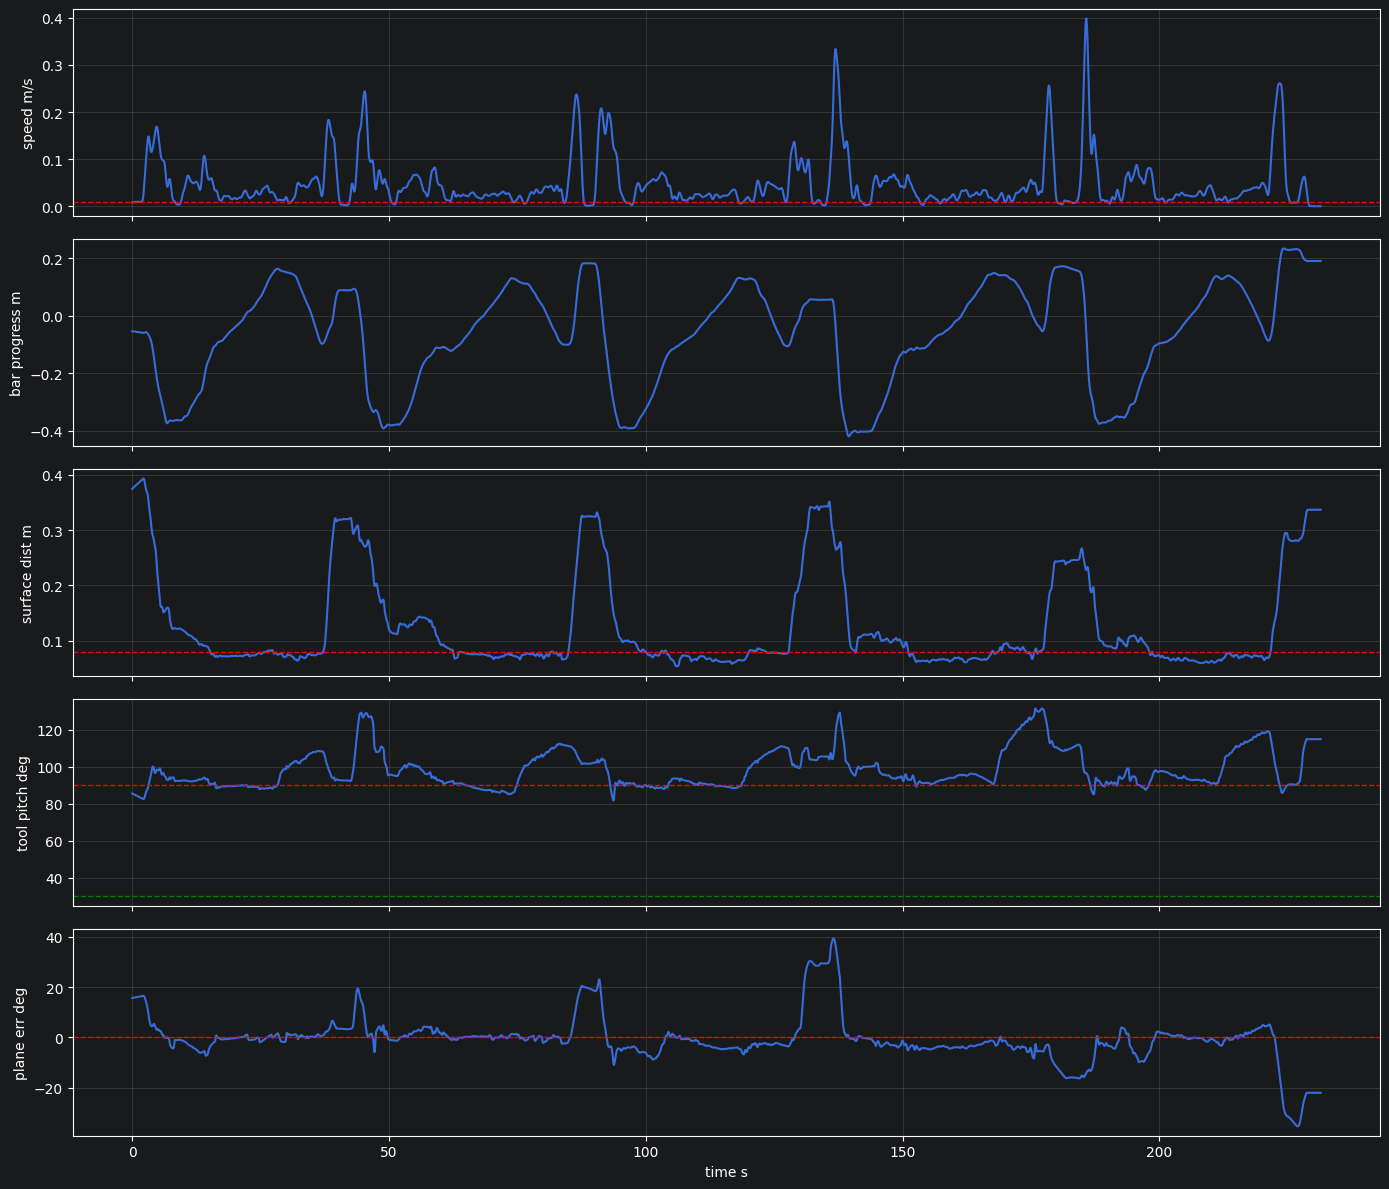

In [5]:
import matplotlib.pyplot as plt

rotations = Rotation.from_quat(trajectory[:, 3:7])
angular_speed = np.r_[0.0, (rotations[:-1].inv() * rotations[1:]).magnitude() / DT]
speed_smooth = gaussian_filter1d(speed, sigma=2.0)
angular_speed_smooth = gaussian_filter1d(angular_speed, sigma=2.0)
progress_smooth = gaussian_filter1d(bar_progress, sigma=1.5)

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
axes[0].plot(time_s, speed_smooth)
axes[0].axhline(0.01, color='r', ls='--', lw=1)
axes[0].set_ylabel('speed m/s')
axes[1].plot(time_s, progress_smooth)
axes[1].set_ylabel('bar progress m')
axes[2].plot(time_s, surface_dist)
axes[2].axhline(env.scan_standoff, color='r', ls='--', lw=1)
axes[2].set_ylabel('surface dist m')
axes[3].plot(time_s, np.rad2deg(tool_pitch))
axes[3].axhline(90, color='r', ls='--', lw=1)
axes[3].axhline(30, color='g', ls='--', lw=1)
axes[3].set_ylabel('tool pitch deg')
axes[4].plot(time_s, np.rad2deg(tool_plane_err))
axes[4].axhline(0, color='r', ls='--', lw=1)
axes[4].set_ylabel('plane err deg')
axes[4].set_xlabel('time s')
for axis in axes:
    axis.grid(alpha=0.25)
fig.tight_layout()
plt.show()

In [6]:
DEMO_WINDOWS_S = [
    (2.3, 40.5),
    (51.4, 88.0),
    (90.0, 134.1),
    (143.9, 182.8),
    (188.0, 229.0),
]
DEMO_START_CONFIDENCE = ['high', 'high', 'high', 'high', 'low']

def first_sustained(mask, start, stop, samples=8):
    values = np.asarray(mask[start:stop], dtype=int)
    if len(values) < samples:
        return None
    count = np.convolve(values, np.ones(samples, dtype=int), mode='valid')
    candidates = np.where(count == samples)[0]
    return None if len(candidates) == 0 else start + int(candidates[0])

def coarse_stage_cuts(start_s, end_s):
    begin = int(np.searchsorted(time_s, start_s))
    end = int(np.searchsorted(time_s, end_s))

    entry_seed_mask = (
        (np.abs(surface_dist - env.scan_standoff) <= 0.015)
        & (np.abs(np.rad2deg(tool_plane_err)) <= 6.0)
        & (np.abs(np.rad2deg(tool_pitch) - 90.0) <= 12.0)
    )
    provisional_s2 = first_sustained(entry_seed_mask, begin, end, samples=12)
    if provisional_s2 is None:
        raise RuntimeError(f'No sustained scan-entry interval in {start_s:.1f}..{end_s:.1f}s')

    reversal = first_sustained(along_speed < -0.008, provisional_s2 + 20, end, samples=5)
    peak_search_end = end if reversal is None else min(end, reversal + 5)
    s3 = provisional_s2 + int(np.argmax(progress_smooth[provisional_s2:peak_search_end]))

    plateau_baseline = float(np.median(surface_dist[max(begin, s3 - 40):s3]))
    plateau_mask = (
        (np.abs(surface_dist - plateau_baseline) <= 0.018)
        & (np.abs(np.rad2deg(tool_plane_err)) <= 8.0)
        & (np.abs(np.rad2deg(tool_pitch) - 90.0) <= 15.0)
    )
    plateau_candidates = [
        index
        for index in range(begin, s3 - 10)
        if np.mean(plateau_mask[index:s3]) >= 0.90
        and np.all(plateau_mask[index:index + 10])
    ]
    s2 = plateau_candidates[0] if plateau_candidates else provisional_s2

    surface_baseline = float(np.median(surface_dist[s2:s3]))
    surface_derivative = np.gradient(gaussian_filter1d(surface_dist, 1.0), DT)
    depart_mask = (
        (surface_dist >= surface_baseline + 0.025)
        & (surface_derivative > 0.012)
    )
    s4 = first_sustained(depart_mask, s3 + 5, end, samples=3)
    if s4 is None:
        s4 = end - 1
    return begin, s2, s3, s4, end

coarse_segments = [coarse_stage_cuts(*window) for window in DEMO_WINDOWS_S]
print('demo | full interval | cuts S1/S2/S3/S4/end | scan distances (+ then -)')
for demo_id, (indices, confidence) in enumerate(zip(coarse_segments, DEMO_START_CONFIDENCE), start=1):
    begin, s2, s3, s4, end = indices
    forward = bar_progress[s3] - bar_progress[s2]
    reverse = bar_progress[s4] - bar_progress[s3]
    print(
        f'{demo_id}: [{time_s[begin]:5.1f}, {time_s[end]:5.1f}] '
        f'cuts=[{time_s[s2]:5.1f}, {time_s[s3]:5.1f}, {time_s[s4]:5.1f}] '
        f'dist=[{forward:+.3f}, {reverse:+.3f}]m start_conf={confidence}'
    )

demo | full interval | cuts S1/S2/S3/S4/end | scan distances (+ then -)
1: [  2.4,  40.6] cuts=[ 12.9,  28.4,  37.6] dist=[+0.439, -0.249]m start_conf=high
2: [ 51.5,  88.1] cuts=[ 61.0,  73.9,  85.3] dist=[+0.243, -0.229]m start_conf=high
3: [ 90.1, 134.2] cuts=[100.0, 118.1, 128.0] dist=[+0.457, -0.233]m start_conf=high
4: [144.0, 182.9] cuts=[151.1, 167.8, 177.6] dist=[+0.268, -0.193]m start_conf=high
5: [188.1, 229.1] cuts=[198.7, 211.1, 221.8] dist=[+0.258, -0.207]m start_conf=low


In [7]:
EQUALITY_LIMITS = {
    'surface_p95_abs_mm': 10.0,
    'pitch_p95_abs_deg': 10.0,
    'plane_p95_abs_deg': 5.0,
}

def trimmed_slice(start, stop, trim_samples=5):
    if stop - start > 2 * trim_samples + 3:
        return slice(start + trim_samples, stop - trim_samples)
    return slice(start, stop)

def equality_stats(values, target):
    error = np.asarray(values) - float(target)
    return {
        'median': float(np.median(values)),
        'std': float(np.std(values)),
        'p95_abs_error': float(np.quantile(np.abs(error), 0.95)),
    }

stage_records = []
for demo_id, (begin, s2, s3, s4, end) in enumerate(coarse_segments, start=1):
    for stage, start, stop, pitch_target in [
        (2, s2, s3, 90.0),
        (3, s3, s4, 30.0),
    ]:
        core = trimmed_slice(start, stop)
        surface_mm = 1000.0 * surface_dist[core]
        pitch_deg = np.rad2deg(tool_pitch[core])
        plane_deg = np.rad2deg(tool_plane_err[core])
        surface_stats = equality_stats(surface_mm, 1000.0 * env.scan_standoff)
        pitch_stats = equality_stats(pitch_deg, pitch_target)
        plane_stats = equality_stats(plane_deg, 0.0)
        tail_start = max(start, stop - 10)
        tail_pitch = np.rad2deg(tool_pitch[tail_start:stop])
        stage_records.append({
            'demo': demo_id,
            'stage': stage,
            'duration_s': (stop - start) * DT,
            'surface': surface_stats,
            'pitch': pitch_stats,
            'plane': plane_stats,
            'tail_pitch_median_deg': float(np.median(tail_pitch)),
            'tail_tilt_from_vertical_deg': float(np.median(np.abs(tail_pitch - 90.0))),
        })

print('Per-demo core statistics (stage boundaries trimmed by 0.5 s):')
print('demo st dur | surface median±std, p95|err| mm | pitch median±std, p95|err| deg | plane median±std, p95|err| deg | S3 tail pitch / tilt')
for record in stage_records:
    surface = record['surface']
    pitch = record['pitch']
    plane = record['plane']
    tail = ''
    if record['stage'] == 3:
        tail = f" | {record['tail_pitch_median_deg']:.1f} / {record['tail_tilt_from_vertical_deg']:.1f}"
    print(
        f"{record['demo']:>4} {record['stage']:>2} {record['duration_s']:>4.1f} | "
        f"{surface['median']:>6.1f}±{surface['std']:<4.1f}, {surface['p95_abs_error']:>5.1f} | "
        f"{pitch['median']:>6.1f}±{pitch['std']:<4.1f}, {pitch['p95_abs_error']:>5.1f} | "
        f"{plane['median']:>6.1f}±{plane['std']:<4.1f}, {plane['p95_abs_error']:>5.1f}{tail}"
    )

print()
print('Pooled pass/fail against diagnostic tolerances:')
for stage, pitch_target in [(2, 90.0), (3, 30.0)]:
    stage_slices = [
        trimmed_slice(s2, s3) if stage == 2 else trimmed_slice(s3, s4)
        for _, s2, s3, s4, _ in coarse_segments
    ]
    pooled_surface = np.concatenate([1000.0 * surface_dist[s] for s in stage_slices])
    pooled_pitch = np.concatenate([np.rad2deg(tool_pitch[s]) for s in stage_slices])
    pooled_plane = np.concatenate([np.rad2deg(tool_plane_err[s]) for s in stage_slices])
    ss = equality_stats(pooled_surface, 80.0)
    ps = equality_stats(pooled_pitch, pitch_target)
    pe = equality_stats(pooled_plane, 0.0)
    print(
        f"stage {stage}: surface p95={ss['p95_abs_error']:.1f}mm "
        f"({'PASS' if ss['p95_abs_error'] <= EQUALITY_LIMITS['surface_p95_abs_mm'] else 'FAIL'}), "
        f"pitch median={ps['median']:.1f}deg p95err={ps['p95_abs_error']:.1f}deg "
        f"({'PASS' if ps['p95_abs_error'] <= EQUALITY_LIMITS['pitch_p95_abs_deg'] else 'FAIL'}), "
        f"plane p95={pe['p95_abs_error']:.1f}deg "
        f"({'PASS' if pe['p95_abs_error'] <= EQUALITY_LIMITS['plane_p95_abs_deg'] else 'FAIL'})"
    )

Per-demo core statistics (stage boundaries trimmed by 0.5 s):
demo st dur | surface median±std, p95|err| mm | pitch median±std, p95|err| deg | plane median±std, p95|err| deg | S3 tail pitch / tilt
   1  2 15.5 |   73.9±6.0 ,  10.9 |   89.4±1.5 ,   3.3 |   -0.6±2.0 ,   6.0
   1  3  9.2 |   73.5±3.5 ,  14.9 |  103.3±3.6 ,  78.3 |    0.4±0.9 ,   1.8 | 108.2 / 18.2
   2  2 12.9 |   75.3±4.3 ,  11.2 |   88.1±2.0 ,   4.0 |    0.1±0.5 ,   0.9
   2  3 11.4 |   74.4±3.7 ,  13.4 |  105.5±6.6 ,  82.0 |   -0.2±1.1 ,   2.4 | 111.3 / 21.3
   3  2 18.1 |   67.3±6.3 ,  21.5 |   90.2±1.6 ,   3.5 |   -3.3±2.7 ,   8.3
   3  3  9.9 |   78.4±5.5 ,  15.2 |  106.0±5.7 ,  80.9 |   -2.8±1.2 ,   6.1 | 110.1 / 20.1
   4  2 16.7 |   65.9±3.2 ,  18.4 |   93.4±1.8 ,   6.0 |   -3.9±0.9 ,   4.7
   4  3  9.8 |   84.2±6.1 ,  14.3 |  120.3±8.9 , 100.5 |   -4.0±1.8 ,   7.0 | 130.8 / 40.8
   5  2 12.4 |   64.6±4.0 ,  20.0 |   93.7±2.1 ,   7.6 |    0.0±1.0 ,   2.0
   5  3 10.7 |   71.9±3.2 ,  14.8 |  112.3±6.5 ,  88.5 |   

In [8]:
print('Empirical equality centers and S3 pitch transitions:')
for stage in (2, 3):
    slices = [
        trimmed_slice(s2, s3) if stage == 2 else trimmed_slice(s3, s4)
        for _, s2, s3, s4, _ in coarse_segments
    ]
    surface_medians = [1000.0 * float(np.median(surface_dist[s])) for s in slices]
    plane_p95 = [float(np.quantile(np.abs(np.rad2deg(tool_plane_err[s])), 0.95)) for s in slices]
    print(
        f'stage {stage}: surface per-demo medians mm={np.round(surface_medians, 1).tolist()}, '
        f'median center={np.median(surface_medians):.1f}mm; '
        f'plane p95 per demo deg={np.round(plane_p95, 1).tolist()}'
    )

for demo_id, (_, _, s3, s4, _) in enumerate(coarse_segments, start=1):
    start_pitch = float(np.median(np.rad2deg(tool_pitch[s3:min(s4, s3 + 10)])))
    end_pitch = float(np.median(np.rad2deg(tool_pitch[max(s3, s4 - 10):s4])))
    print(
        f'demo {demo_id} S3 pitch: start={start_pitch:.1f}deg, '
        f'end={end_pitch:.1f}deg, change={end_pitch - start_pitch:+.1f}deg'
    )

Empirical equality centers and S3 pitch transitions:
stage 2: surface per-demo medians mm=[73.9, 75.3, 67.3, 65.9, 64.6], median center=67.3mm; plane p95 per demo deg=[6.0, 0.9, 8.3, 4.7, 2.0]
stage 3: surface per-demo medians mm=[73.5, 74.4, 78.4, 84.2, 71.9], median center=74.4mm; plane p95 per demo deg=[1.8, 2.4, 6.1, 7.0, 4.7]
demo 1 S3 pitch: start=95.7deg, end=108.2deg, change=+12.5deg
demo 2 S3 pitch: start=86.1deg, end=111.3deg, change=+25.2deg
demo 3 S3 pitch: start=89.6deg, end=110.1deg, change=+20.4deg
demo 4 S3 pitch: start=95.7deg, end=130.8deg, change=+35.1deg
demo 5 S3 pitch: start=92.4deg, end=118.6deg, change=+26.2deg


In [9]:
processed_dir = PROJECT_ROOT / 'robot/stage_cons_iiwa14/data/processed'
processed_dir.mkdir(parents=True, exist_ok=True)
processed_path = processed_dir / 'demo_01_10hz_coarse.npz'

demo_id_trace = np.full(len(time_s), -1, dtype=int)
stage_label_trace = np.full(len(time_s), -1, dtype=int)
for demo_id, (begin, s2, s3, s4, end) in enumerate(coarse_segments):
    demo_id_trace[begin:end] = demo_id
    stage_label_trace[begin:s2] = 0
    stage_label_trace[s2:s3] = 1
    stage_label_trace[s3:s4] = 2
    stage_label_trace[s4:end] = 3

bounds_indices = np.asarray(coarse_segments, dtype=int)
bounds_times_s = time_s[bounds_indices]
np.savez_compressed(
    processed_path,
    timestamps=time_s,
    joint_positions=joint_q,
    trajectory=trajectory,
    features=features,
    feature_names=np.asarray(feature_names),
    locked_bar_pose=locked_bar,
    locked_obstacle_pose=locked_obs,
    demo_id=demo_id_trace,
    coarse_stage_labels=stage_label_trace,
    coarse_bounds_indices=bounds_indices,
    coarse_bounds_times_s=bounds_times_s,
    demo_start_confidence=np.asarray(DEMO_START_CONFIDENCE),
    downsample_hz=np.asarray(TARGET_HZ),
    source_bag=np.asarray(str(BAG_PATH)),
    scene_policy=np.asarray('whole_recording_robust_static_lock'),
)
print('saved:', processed_path)
print('shape trajectory/features:', trajectory.shape, features.shape)
print('bounds columns: [demo_start, stage2_start, stage3_start, stage4_start, demo_end]')
print(np.round(bounds_times_s, 1))

saved: /home/baiyu/LearnStageConstraints/robot/stage_cons_iiwa14/data/processed/demo_01_10hz_coarse.npz
shape trajectory/features: (2315, 7) (2315, 8)
bounds columns: [demo_start, stage2_start, stage3_start, stage4_start, demo_end]
[[  2.4  12.9  28.4  37.6  40.6]
 [ 51.5  61.   73.9  85.3  88.1]
 [ 90.1 100.  118.1 128.  134.2]
 [144.  151.1 167.8 177.6 182.9]
 [188.1 198.7 211.1 221.8 229.1]]


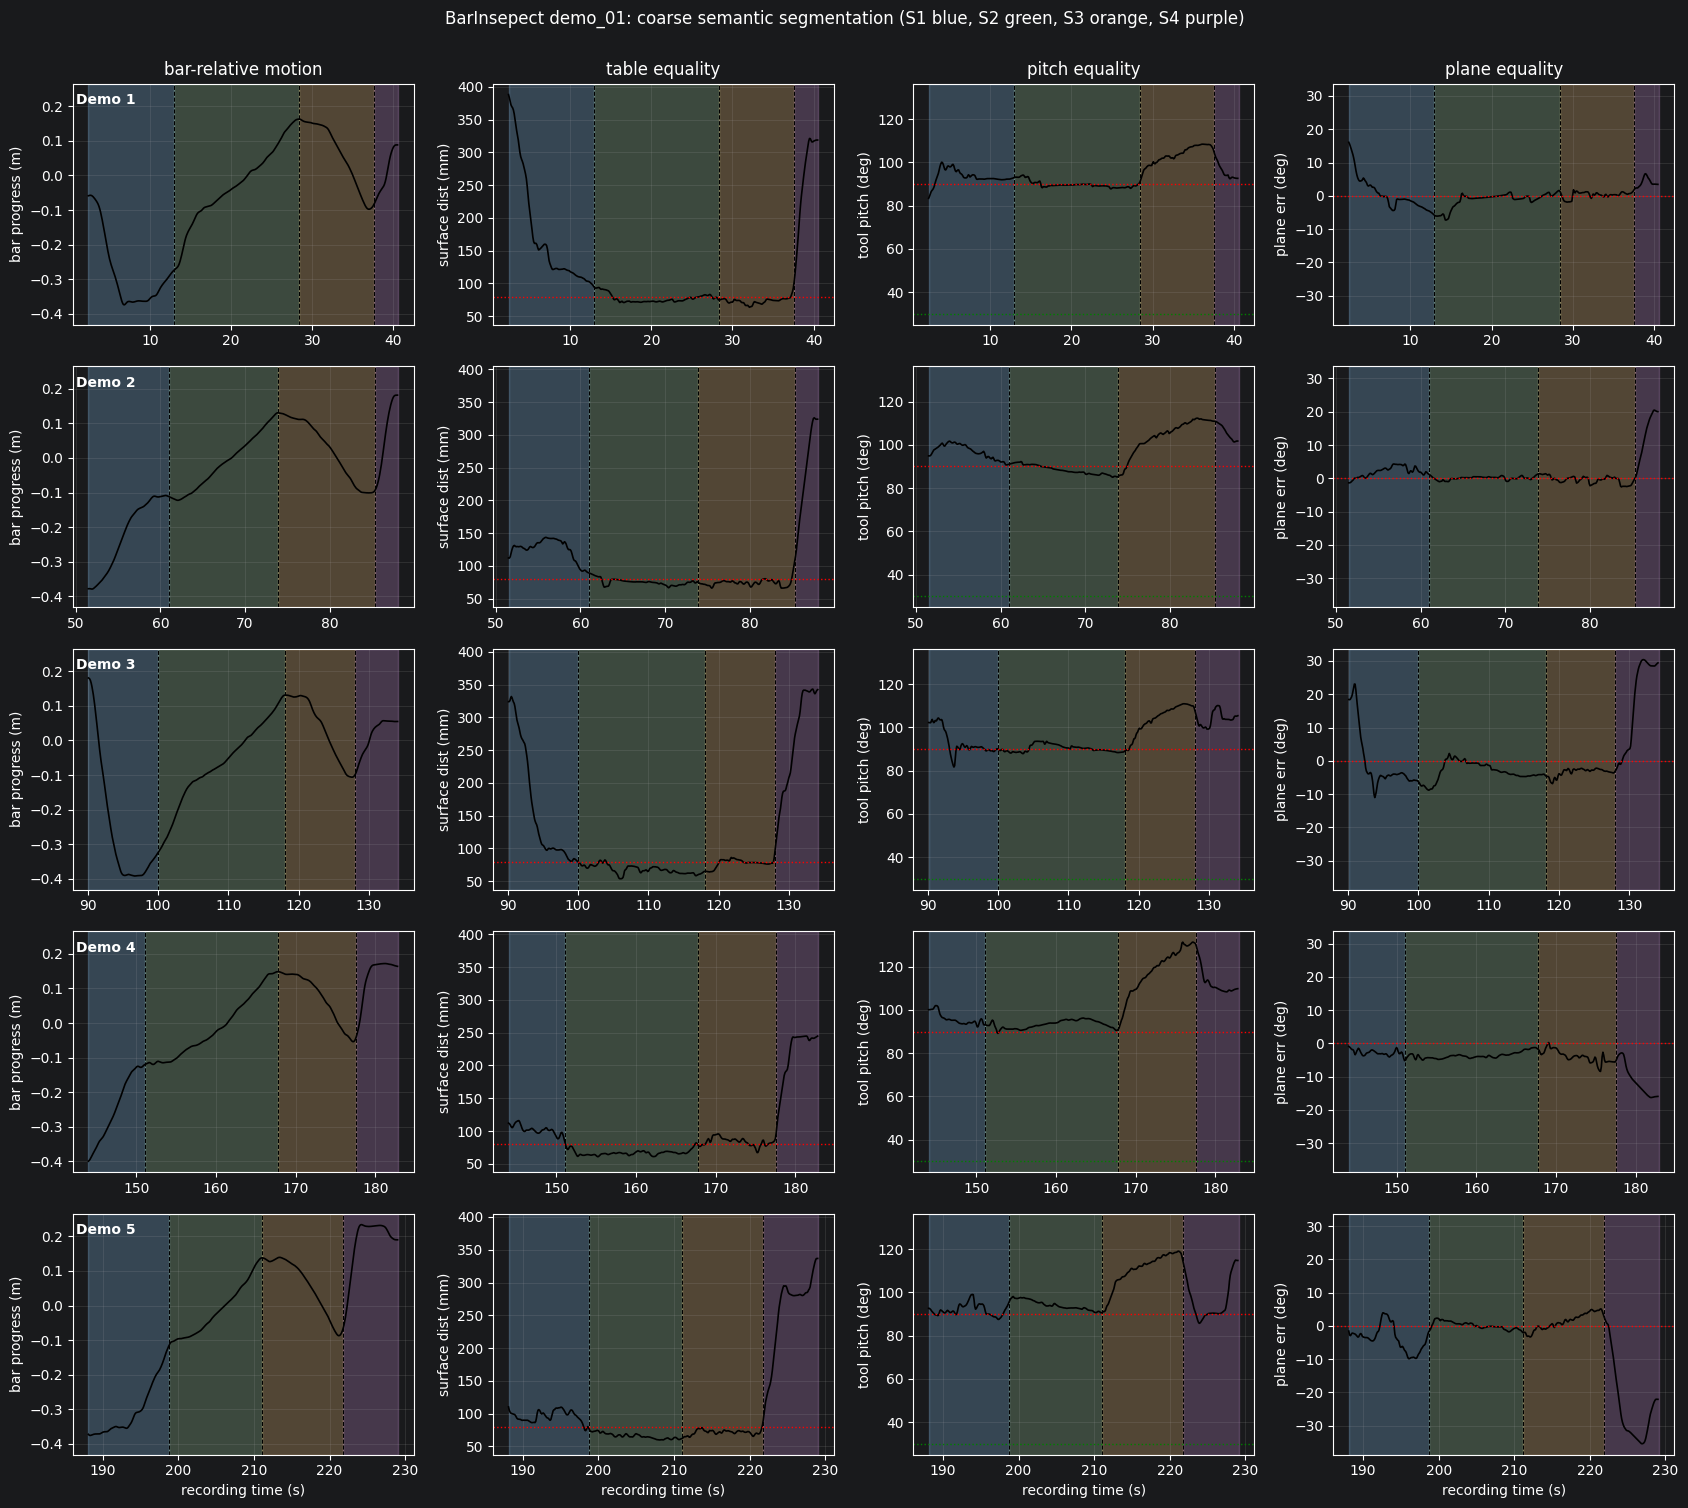

shared y-limits:
  bar progress (m): -0.431 to 0.265
  surface dist (mm): 37.133 to 405.041
  tool pitch (deg): 24.932 to 136.426
  plane err (deg): -38.700 to 33.706
saved: /home/baiyu/LearnStageConstraints/robot/stage_cons_iiwa14/data/processed/demo_01_coarse_segmentation.png


In [11]:
stage_colors = ['#90caf9', '#a5d6a7', '#ffcc80', '#ce93d8']
fig, axes = plt.subplots(5, 4, figsize=(17, 15), squeeze=False)
series = [
    (progress_smooth, 'bar progress (m)'),
    (1000.0 * surface_dist, 'surface dist (mm)'),
    (np.rad2deg(tool_pitch), 'tool pitch (deg)'),
    (np.rad2deg(tool_plane_err), 'plane err (deg)'),
]

# Use one common y-axis range per feature across every plotted demo.
# Include the equality-reference lines so that the scale never clips a target.
demo_mask = np.zeros(len(time_s), dtype=bool)
for begin, _, _, _, end in coarse_segments:
    demo_mask[begin:end] = True

reference_values = [[], [80.0], [90.0, 30.0], [0.0]]
minimum_padding = [0.02, 10.0, 5.0, 3.0]
shared_ylims = []
for col, (values, _) in enumerate(series):
    plotted_values = np.asarray(values)[demo_mask]
    scale_values = np.concatenate([
        plotted_values[np.isfinite(plotted_values)],
        np.asarray(reference_values[col], dtype=float),
    ])
    lower = float(np.min(scale_values))
    upper = float(np.max(scale_values))
    padding = max(0.05 * (upper - lower), minimum_padding[col])
    shared_ylims.append((lower - padding, upper + padding))

for row, (begin, s2, s3, s4, end) in enumerate(coarse_segments):
    cuts = [begin, s2, s3, s4, end]
    for col, (values, ylabel) in enumerate(series):
        ax = axes[row, col]
        ax.plot(time_s[begin:end], values[begin:end], color='black', lw=1.2)
        for stage in range(4):
            ax.axvspan(time_s[cuts[stage]], time_s[cuts[stage + 1]], color=stage_colors[stage], alpha=0.25)
        for cut in cuts[1:-1]:
            ax.axvline(time_s[cut], color='black', ls='--', lw=0.8)
        ax.set_ylim(*shared_ylims[col])
        ax.grid(alpha=0.2)
        ax.set_ylabel(ylabel)
        if row == 0:
            ax.set_title(['bar-relative motion', 'table equality', 'pitch equality', 'plane equality'][col])
        if row == 4:
            ax.set_xlabel('recording time (s)')
    axes[row, 0].text(
        0.01, 0.96, f'Demo {row + 1}',
        transform=axes[row, 0].transAxes, va='top', fontweight='bold'
    )
    axes[row, 1].axhline(80.0, color='red', ls=':', lw=1.0)
    axes[row, 2].axhline(90.0, color='red', ls=':', lw=1.0)
    axes[row, 2].axhline(30.0, color='green', ls=':', lw=1.0)
    axes[row, 3].axhline(0.0, color='red', ls=':', lw=1.0)

fig.suptitle('BarInsepect demo_01: coarse semantic segmentation (S1 blue, S2 green, S3 orange, S4 purple)', y=1.002)
fig.tight_layout()
segmentation_plot_path = processed_dir / 'demo_01_coarse_segmentation.png'
fig.savefig(segmentation_plot_path, dpi=160, bbox_inches='tight')
plt.show()
print('shared y-limits:')
for (_, ylabel), ylim in zip(series, shared_ylims):
    print(f'  {ylabel}: {ylim[0]:.3f} to {ylim[1]:.3f}')
print('saved:', segmentation_plot_path)